In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# test signal
一个正弦调制频率的正弦波  
sr = 48000       # 采样率
fc = 3000        # 载波频率 (Hz)
fm = 1           # 调制频率 (Hz)
delta_f = 1000   # 频率偏置 (Hz)
fft_size = 2048
zero_pad = 2
hop_size = 512
total_len = hop_size * 512

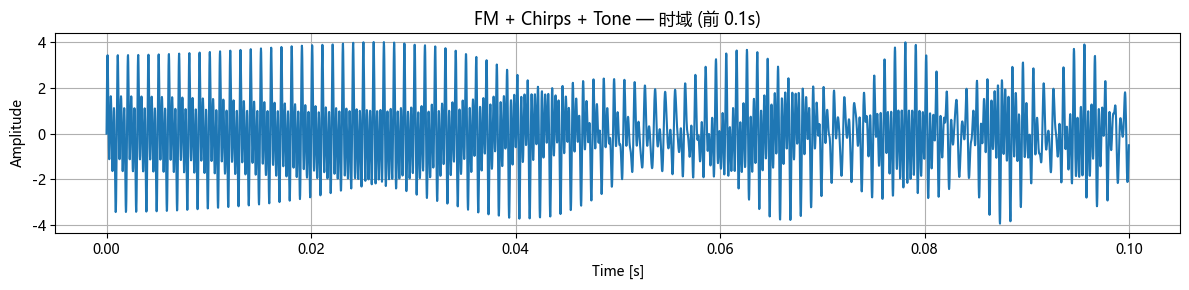

In [67]:
sr = 48000
fft_size = 2048
zero_pad = 2
hop_size = 256
total_len = fft_size * 128

t = np.arange(total_len) / sr
T = total_len / sr  # 总时长

# 原 FM 调制正弦波（载波 2k，调制 1Hz，频偏 1k）
fc = 2000.0
fm = 1.0
delta_f = 1000.0
beta = delta_f / fm
fm_sig = np.sin(2 * np.pi * fc * t + beta * np.sin(2 * np.pi * fm * t))

# 两个线性 chirp：1k→4k 和 4k→1k
chirp_up = np.sin(2 * np.pi * (1000 * t + (3000 - 1000) / (2 * T) * t**2))
chirp_down = np.sin(2 * np.pi * (3000 * t + (1000 - 3000) / (2 * T) * t**2))

# 2k 纯音
tone_2k = np.sin(2 * np.pi * 2000 * t)

y = fm_sig + chirp_up + chirp_down + tone_2k

plt.figure(figsize=(12, 3))
plt.plot(t[:4800], y[:4800])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("FM + Chirps + Tone — 时域 (前 0.1s)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 经典频谱图

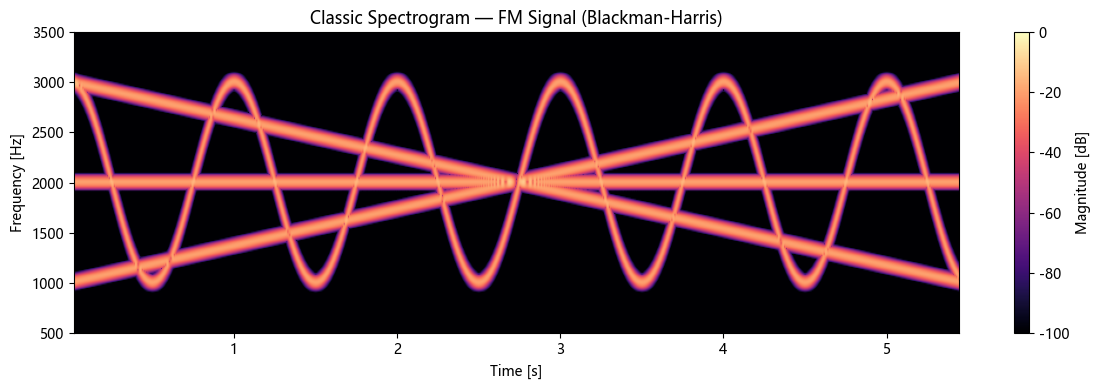

In [69]:
window = signal.windows.blackmanharris(fft_size)
plt.figure(figsize=(12, 4))
plt.specgram(
    y,
    NFFT=fft_size,
    Fs=sr,
    noverlap=fft_size - hop_size,
    window=window,
    pad_to=fft_size * zero_pad,
    scale="dB",
    cmap="magma",
    vmin=-100,
    vmax=0,
)
plt.ylim(500, 3500)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("Classic Spectrogram — FM Signal (Blackman-Harris)")
plt.colorbar(label="Magnitude [dB]")
plt.tight_layout()
plt.show()

# 只做频率重新分配

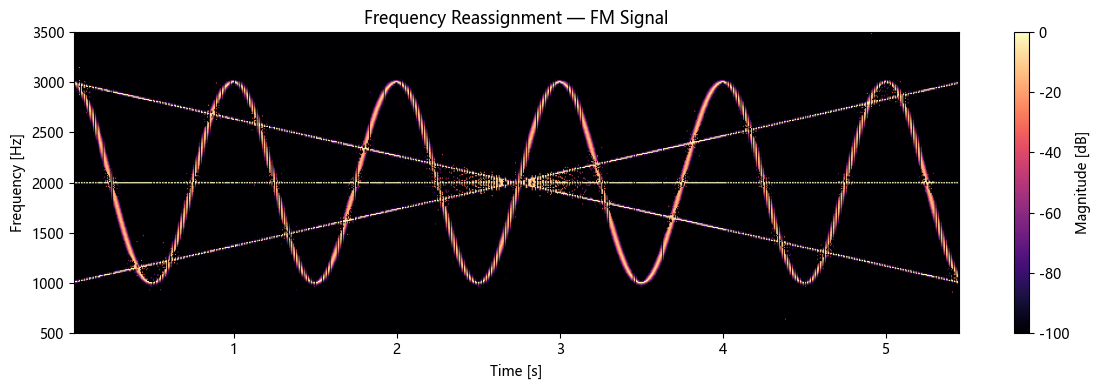

In [70]:
n_fft = fft_size
fft_len = n_fft * zero_pad
hop = hop_size
n_frames = (len(y) - n_fft) // hop + 1
n_freq_out = fft_len // 2 + 1

w = signal.windows.blackmanharris(n_fft)

Z_w = np.zeros((n_freq_out, n_frames), dtype=complex)
Z_pt = np.zeros_like(Z_w)
for m in range(n_frames):
    seg = y[m * hop : m * hop + n_fft]
    Z_w[:, m] = np.fft.rfft(seg * w, n=fft_len)
    seg_shift = np.roll(seg, 1)
    seg_shift[0] = 0.0
    Z_pt[:, m] = np.fft.rfft(seg_shift * w, n=fft_len)

cross_t = Z_w * np.conj(Z_pt)
inst_freq = np.angle(cross_t) / (2 * np.pi) % 1.0
inst_freq_hz = inst_freq * sr

mag_lin = np.abs(Z_w) / n_fft
f_bins = np.fft.rfftfreq(fft_len, 1 / sr)
t_centers = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

# 用零填充后的频率分辨率做输出网格
T_grid = np.broadcast_to(t_centers, inst_freq_hz.shape)
hist, x_e, y_e = np.histogram2d(
    T_grid.flatten(),
    inst_freq_hz.flatten(),
    weights=mag_lin.flatten(),
    bins=(n_frames, n_freq_out),
    range=((t_centers[0], t_centers[-1] + hop / sr), (0, sr / 2)),
)
hist_db = 20 * np.log10(hist.T + 1e-12)

extent = [t_centers[0], t_centers[-1] + hop / sr, 0, sr / 2]
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(
    hist_db, aspect="auto", origin="lower", cmap="magma", extent=extent, vmin=-100, vmax=0
)
ax.set_ylim(500, 3500)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Frequency Reassignment — FM Signal")
fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(-100, 0), cmap="magma"),
    ax=ax,
    label="Magnitude [dB]",
)
fig.tight_layout()
plt.show()

# 只做时间重新分配

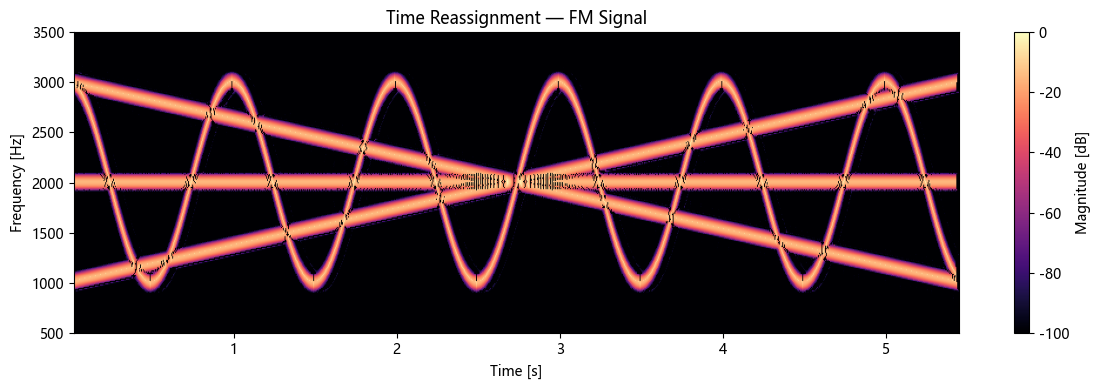

In [71]:
Z_pf = np.roll(Z_w, 1, axis=0)
Z_pf[0, :] = 0.0

cross_f = Z_w * np.conj(Z_pf)
arg_f = np.mod(np.angle(cross_f) / (2 * np.pi), 1.0)
group_delay = 0.5 - arg_f
frame_dur = n_fft / sr
t_reassigned = t_centers[np.newaxis, :] + group_delay * frame_dur

T_grid = np.broadcast_to(t_centers, t_reassigned.shape)
F_grid = np.broadcast_to(f_bins[:, None], t_reassigned.shape)

# 输出网格用零填充后的频率分辨率
hist, x_e, y_e = np.histogram2d(
    t_reassigned.flatten(),
    F_grid.flatten(),
    weights=mag_lin.flatten(),
    bins=(n_frames, n_freq_out),
    range=((t_centers[0], t_centers[-1] + hop / sr), (0, sr / 2)),
)
hist_db = 20 * np.log10(hist.T + 1e-12)

extent = [t_centers[0], t_centers[-1] + hop / sr, 0, sr / 2]
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(
    hist_db, aspect="auto", origin="lower", cmap="magma", extent=extent, vmin=-100, vmax=0
)
ax.set_ylim(500, 3500)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Time Reassignment — FM Signal")
fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(-100, 0), cmap="magma"),
    ax=ax,
    label="Magnitude [dB]",
)
fig.tight_layout()
plt.show()

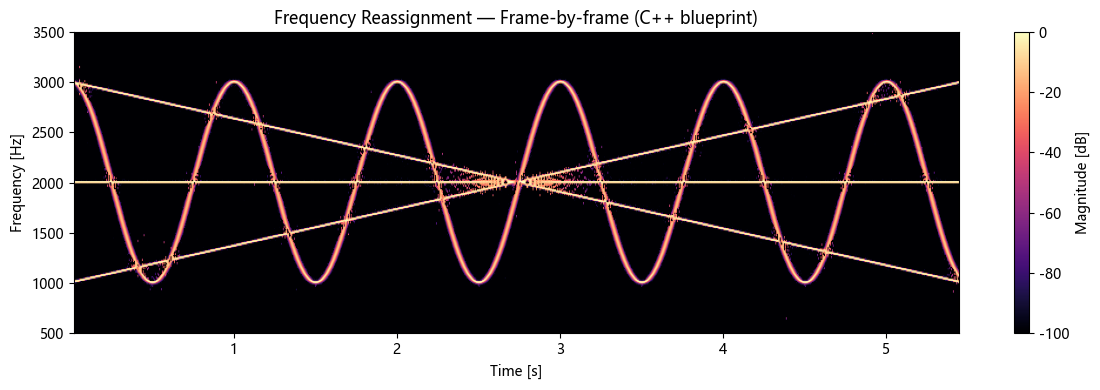

In [72]:
# ------------------------------------------------------------
# 频率重分配 — 逐帧处理版（带零填充）
# ------------------------------------------------------------
# 核心思路:
#   每个 bin 的能量从 FFT 中心频率"重新分配"到瞬时频率位置
#   时间轴不变（每帧一列），频率轴沿 y 方向移动
#
# 瞬时频率 (instantaneous frequency) 推导:
#   对信号做时移 1 样本: x'[n] = x[n-1], x'[0] = 0
#   计算时移 STFT: X_t = FFT(x' * w)
#   互谱: cross[k] = X_h[k] · conj(X_t[k])
#   相位差 Δφ = angle(cross) 反映了时移 1 样本的频率信息
#   inst_freq_norm = mod(Δφ / 2π, 1)    → [0, 1)  归一化频率
#   inst_freq_hz   = inst_freq_norm · sr → [0, sr) 物理频率
#
#   纯音验证: 若 x[n] = A·exp(j2πfn/N)
#     则 x[n-1] = x[n] · exp(-j2πf/N)
#     X_t[k] ≈ X_h[k] · exp(-j2πf/N)
#     cross = |X_h|² · exp(j2πf/N)
#     angle(cross) / 2π = f/N   → 准确恢复频率 f
#
# 叠加方式:
#   第 m 帧时间列固定: t_idx = m
#   频率方向做线性分布: 相邻两行按小数部分加权
#   grid[t_idx, f_idx]     += mag × (1 - f_frac)
#   grid[t_idx, f_idx + 1] += mag × f_frac
#
# 参考: tfr-master (github.com/bzamecnik/tfr)
#   estimate_instant_freqs → arg(crossTimeSpectrum)
#   LinearTransform → 保留线性频率轴
# ============================================================

n_fft = fft_size
fft_len = n_fft * zero_pad
hop = hop_size
sr = 48000
n_freq_in = n_fft // 2 + 1      # 原始频率 bin 数
n_freq_out = fft_len // 2 + 1   # 零填充后频率 bin 数

w = signal.windows.blackmanharris(n_fft)

n_frames = (len(y) - n_fft) // hop + 1

# 输出网格: (时间帧 × 零填充后频率 bin)
grid = np.zeros((n_frames, n_freq_out))

# 频率轴（输出网格的 y 轴，单位 Hz）
freq_axis = np.fft.rfftfreq(fft_len, 1 / sr)
# 时间轴（输出网格的 x 轴）
time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

for m in range(n_frames):
    # 1. 取第 m 帧
    seg = y[m * hop : m * hop + n_fft]

    # 2. 标准 STFT: X_h = FFT(x * w, n=fft_len)  零填充
    X_h = np.fft.rfft(seg * w, n=fft_len)

    # 3. 时移 STFT: 信号右移 1 样本 → FFT(x[n-1] * w[n], n=fft_len)
    seg_shift = np.roll(seg, 1)
    seg_shift[0] = 0.0
    X_t = np.fft.rfft(seg_shift * w, n=fft_len)

    # 4. 互谱 → 瞬时频率
    cross = X_h * np.conj(X_t)
    inst_freq_norm = np.mod(np.angle(cross) / (2 * np.pi), 1.0)
    inst_freq_hz = inst_freq_norm * sr

    # 5. 线性幅度（作为能量权重）
    mag_lin = np.abs(X_h) / n_fft

    # 6. 第 m 帧的输出时间索引
    t_idx = m  # 每个输出时间帧对应一个输入帧

    # 7. 逐个 bin 将能量叠到输出网格（频率方向线性分布）
    for k in range(n_freq_out):
        f_reassigned = inst_freq_hz[k]

        # 浮点频率索引，线性分配给相邻两行
        f_pos = f_reassigned / (sr / 2) * (n_freq_out - 1)
        f_idx = int(np.floor(f_pos))
        f_frac = f_pos - f_idx

        f_idx = np.clip(f_idx, 0, n_freq_out - 2)
        grid[t_idx, f_idx] += mag_lin[k] * (1 - f_frac)
        grid[t_idx, f_idx + 1] += mag_lin[k] * f_frac

# 转 dB 显示
grid_db = 20 * np.log10(grid.T + 1e-12)

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(
    grid_db,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=[time_axis[0], time_axis[-1] + hop / sr, 0, sr / 2],
    vmin=-100,
    vmax=0,
)
ax.set_ylim(500, 3500)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Frequency Reassignment — Frame-by-frame (C++ blueprint)")
fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(-100, 0), cmap="magma"),
    ax=ax,
    label="Magnitude [dB]",
)
fig.tight_layout()
plt.show()

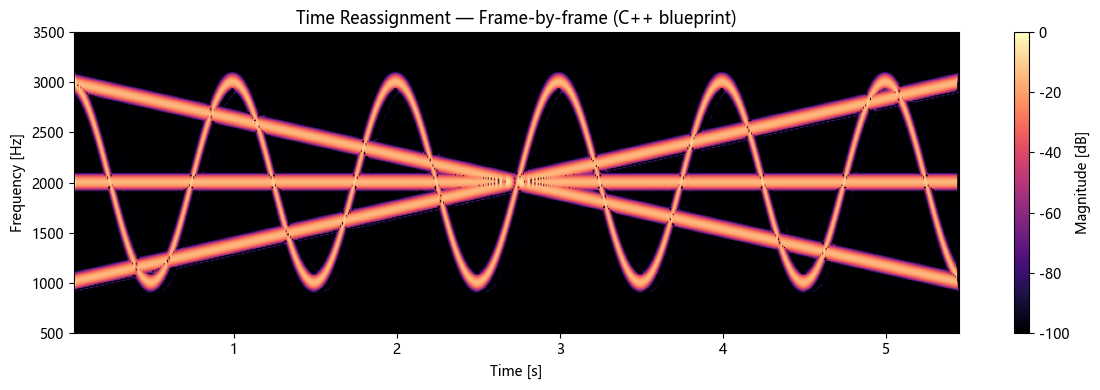

In [73]:
# ------------------------------------------------------------
# 时间重分配 — 逐帧处理版（带零填充）
# ------------------------------------------------------------
# 核心思路:
#   频率重分配 → 同一时间列内，每个 bin 沿频率轴移动到瞬时频率位置
#   时间重分配 → 同一频率行内，每个 bin 沿时间轴移动到群延迟位置
#
# 因此时间重分配需要"跨列"叠加能量:
#   第 m 帧的 bin k,
#     频率不变: 频率索引 = k
#     时间偏移: t' = t_center[m] + group_delay[k] × frame_duration
#     → 能量从时间列 m 分散到 t' 附近的若干列
#
# 群延迟 (group delay) 范围:
#   arg(z)       = mod(angle(z) / 2π, 1.0)           → [0, 1)
#   group_delay  = 0.5 - arg(z)                      → (-0.5, 0.5]
#   0 = 帧中心, ±0.5 = 帧左右边缘
#
# 最大偏移列数:
#   max_shift_samples = 0.5 × n_fft = 1024
#   hop = 256 samples
#   max_shift_columns = 1024 / 256 = 4
#   → 能量最多跨越 m-4 到 m+4 列
#
# 叠加方式:
#   t_frac 是 t_reassigned 在两列之间的小数位置
#   grid[t_idx]     += mag × (1 - t_frac)   左列
#   grid[t_idx + 1] += mag × t_frac         右列
#   线性分配避免量化跳变
#
# 参考: tfr-master (github.com/bzamecnik/tfr)
#   estimate_group_delays → 0.5 - arg(crossFreqSpectrum)
#   histogram2d 等价于逐帧逐 bin 累加 + 线性插值
# ============================================================

n_fft = fft_size
fft_len = n_fft * zero_pad
hop = hop_size
sr = 48000

w = signal.windows.blackmanharris(n_fft)

n_frames = (len(y) - n_fft) // hop + 1
frame_dur = n_fft / sr

n_freq_out = fft_len // 2 + 1
grid = np.zeros((n_frames, n_freq_out))

freq_axis = np.fft.rfftfreq(fft_len, 1 / sr)
time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

for m in range(n_frames):
    seg = y[m * hop : m * hop + n_fft]

    # 1. 标准 STFT: X_h = FFT(x * w, n=fft_len)  零填充
    X_h = np.fft.rfft(seg * w, n=fft_len)

    # 2. 频移 STFT: X 右移 1 bin（频域移位，用于时间重分配）
    X_pf = np.roll(X_h, 1)
    X_pf[0] = 0.0

    # 3. 互谱 → 群延迟
    cross = X_h * np.conj(X_pf)
    arg_f = np.mod(np.angle(cross) / (2 * np.pi), 1.0)
    group_delay = 0.5 - arg_f  # (-0.5, 0.5]

    # 4. 线性幅度
    mag_lin = np.abs(X_h) / n_fft

    # 5. 逐个 bin：频率不变，时间重新分配 → 跨列叠加
    t_center = time_axis[m]
    for k in range(n_freq_out):
        t_reassigned = t_center + group_delay[k] * frame_dur

        # 输出网格浮点时间索引
        t_pos = (t_reassigned - time_axis[0]) / (hop / sr)
        t_idx = int(np.floor(t_pos))
        t_frac = t_pos - t_idx  # [0, 1) 小数部分

        # 线性分配能量给相邻两列
        t_idx = np.clip(t_idx, 0, n_frames - 2)
        grid[t_idx, k] += mag_lin[k] * (1 - t_frac)
        grid[t_idx + 1, k] += mag_lin[k] * t_frac

# 转 dB 显示
grid_db = 20 * np.log10(grid.T + 1e-12)

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(
    grid_db,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=[time_axis[0], time_axis[-1] + hop / sr, 0, sr / 2],
    vmin=-100,
    vmax=0,
)
ax.set_ylim(500, 3500)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Time Reassignment — Frame-by-frame (C++ blueprint)")
fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(-100, 0), cmap="magma"),
    ax=ax,
    label="Magnitude [dB]",
)
fig.tight_layout()
plt.show()

# 时间-频率重新分配

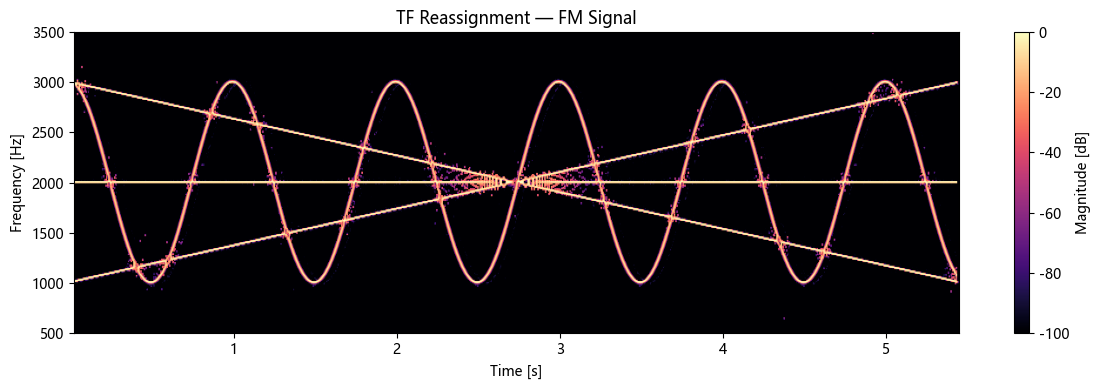

In [74]:
def reassigned_spectrogram_tf(
    y,
    sr,
    n_fft=2048,
    hop=256,
    zero_pad=1,
    window=None,
    vmin=-100,
    vmax=0,
    f_lim=(1500, 4500),
    title=None,
):
    """时间-频率重分配频谱图（逐 bin 同时分配，C++ 移植蓝图）

    对每个 bin 同时计算频率校正(inst_freq)和时间校正(group_delay)，
    将能量二维线性分配到 4 个相邻格点。

    参数:
        y: 1D 输入信号
        sr: 采样率 (Hz)
        n_fft: FFT 大小
        hop: 帧移
        zero_pad: 零填充因子 (1=不填充，2=2倍，4=4倍...)
        window: 窗函数 (None 则用 Blackman-Harris)
        vmin/vmax: dB 显示范围
        f_lim: 频率显示范围 (Hz) 或 None
        title: 图标题

    返回:
        grid: (n_time, n_freq) 线性幅度网格
        time_axis: 时间轴 (秒)
        freq_axis: 频率轴 (Hz)
    """
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1
    if window is None:
        w = signal.windows.blackmanharris(n_fft)
    else:
        w = window

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr
    f_max = sr / 2

    grid = np.zeros((n_frames, n_freq_out))
    freq_axis = np.fft.rfftfreq(fft_len, 1 / sr)
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)

        seg_shift = np.roll(seg, 1)
        seg_shift[0] = 0.0
        X_t = np.fft.rfft(seg_shift * w, n=fft_len)
        cross_t = X_h * np.conj(X_t)
        inst_freq_hz = np.mod(np.angle(cross_t) / (2 * np.pi), 1.0) * sr

        X_pf = np.roll(X_h, 1)
        X_pf[0] = 0.0
        cross_f = X_h * np.conj(X_pf)
        arg_f = np.mod(np.angle(cross_f) / (2 * np.pi), 1.0)
        group_delay = 0.5 - arg_f

        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        for k in range(n_freq_out):
            f_reassigned = np.clip(inst_freq_hz[k], 0, f_max)
            f_pos = f_reassigned / f_max * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

    # ----- 绘制（线性频率轴）-----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, 0, f_max]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    if f_lim:
        ax.set_ylim(*f_lim)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "Time-Frequency Reassignment")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()

    return grid, time_axis, freq_axis


# 使用例
grid_tf, t_axis, f_axis = reassigned_spectrogram_tf(
    y, sr, zero_pad=zero_pad, title="TF Reassignment — FM Signal", f_lim=(500, 3500)
)

# 现在制作一个对数版本

In [75]:
# ------------------------------------------------------------
# 纯对数版本 — 频率重分配（带零填充）
# ------------------------------------------------------------
# 在 log10 空间构建等距网格:
#   log_f_axis = linspace(log10(f_min), log10(f_max), N)
#   f_axis     = 10^log_f_axis      ← 等比数列
#
# 频率重分配时:
#   inst_freq 转为 log10 → 在线性 log 网格上做线性分布
# 时间重分配不变
# ============================================================


def reassigned_spectrogram_log(
    y,
    sr,
    n_fft=2048,
    hop=256,
    zero_pad=1,
    window=None,
    vmin=-100,
    vmax=0,
    f_lim=(40, 8000),
    title=None,
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1
    if window is None:
        w = signal.windows.blackmanharris(n_fft)
    else:
        w = window

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    # log 空间等距网格
    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)

        seg_shift = np.roll(seg, 1)
        seg_shift[0] = 0.0
        X_t = np.fft.rfft(seg_shift * w, n=fft_len)
        cross_t = X_h * np.conj(X_t)
        inst_freq_hz = np.mod(np.angle(cross_t) / (2 * np.pi), 1.0) * sr

        X_pf = np.roll(X_h, 1)
        X_pf[0] = 0.0
        cross_f = X_h * np.conj(X_pf)
        arg_f = np.mod(np.angle(cross_f) / (2 * np.pi), 1.0)
        group_delay = 0.5 - arg_f

        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        for k in range(n_freq_out):
            f_reassigned = np.clip(inst_freq_hz[k], f_min, f_max)
            # 转 log10 → 在 log 空间做线性分布
            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

    # ----- 绘制 -----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, freq_axis[0], freq_axis[-1]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    ax.set_ylim(f_min, f_max)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "TF Reassignment (Log Freq)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()

    return grid, time_axis, freq_axis

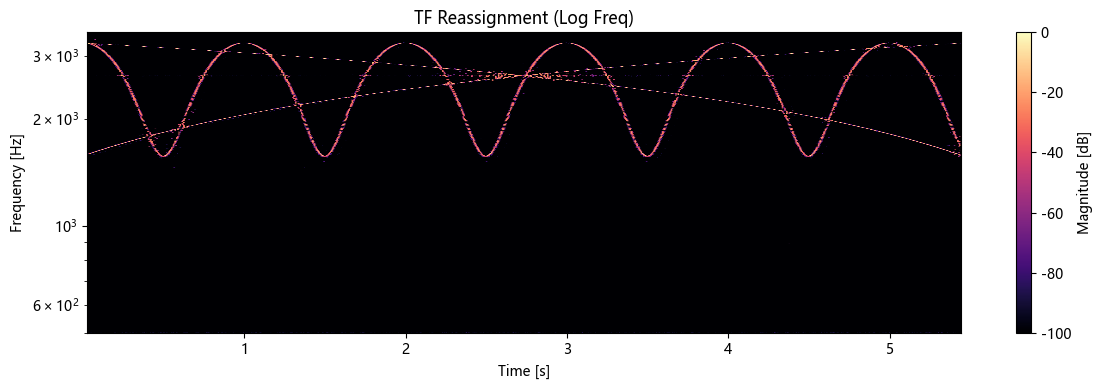

(array([[9.83262493e-08, 0.00000000e+00, 0.00000000e+00, ...,
         1.40658962e-07, 1.43271201e-07, 7.91710941e-08],
        [3.44289906e-06, 6.37729182e-11, 6.39052514e-10, ...,
         1.18773199e-07, 1.22334294e-07, 5.79558735e-08],
        [6.15679246e-06, 2.59447424e-09, 2.59985796e-08, ...,
         1.91960194e-07, 2.10451615e-07, 1.10262392e-07],
        ...,
        [8.84753044e-06, 0.00000000e+00, 0.00000000e+00, ...,
         2.68716013e-07, 3.67902351e-08, 0.00000000e+00],
        [5.28230871e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.79886351e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
       shape=(1017, 2049)),
 array([0.02132292, 0.02665625, 0.03198958, ..., 5.42932292, 5.43465625,
        5.43998958], shape=(1017,)),
 array([ 500.        ,  500.47530149,  500.9510548 , ..., 3493.35525543,
        3496.67604934, 3500.        ], shape=(2049,)))

In [76]:
reassigned_spectrogram_log(y, sr, f_lim=(500, 3500), zero_pad=2)

In [56]:
def reassigned_spectrogram_tf_log(
    y,
    sr,
    n_fft=2048,
    hop=256,
    zero_pad=1,
    window=None,
    vmin=-100,
    vmax=0,
    f_lim=(1500, 4500),
    title=None,
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1
    if window is None:
        w = signal.windows.blackmanharris(n_fft)
    else:
        w = window

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr
    f_max = sr / 2

    grid = np.zeros((n_frames, n_freq_out))
    freq_axis = np.fft.rfftfreq(fft_len, 1 / sr)
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)

        seg_shift = np.roll(seg, 1)
        seg_shift[0] = 0.0
        X_t = np.fft.rfft(seg_shift * w, n=fft_len)
        cross_t = X_h * np.conj(X_t)
        inst_freq_hz = np.mod(np.angle(cross_t) / (2 * np.pi), 1.0) * sr

        X_pf = np.roll(X_h, 1)
        X_pf[0] = 0.0
        cross_f = X_h * np.conj(X_pf)
        arg_f = np.mod(np.angle(cross_f) / (2 * np.pi), 1.0)
        group_delay = 0.5 - arg_f

        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        for k in range(n_freq_out):
            f_reassigned = np.clip(inst_freq_hz[k], 0, f_max)
            f_pos = f_reassigned / f_max * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

    # ----- 绘制（对数 y 轴）-----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, 0, f_max]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    if f_lim:
        ax.set_ylim(*f_lim)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "Time-Frequency Reassignment (Log Display)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()

    return grid, time_axis, freq_axis